In [13]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
import matplotlib.pyplot as plt


In [14]:
train_data = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\train_data.csv")
test_data  = pd.read_csv(r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\test_data.csv")


In [15]:
feature_cols = [
    "LivingArea", "BedroomsTotal", "BathroomsTotalInteger",
    "LotSizeSquareFeet", "YearBuilt", "Stories",
    "GarageSpaces", "ParkingTotal",
    "AttachedGarageYN", "FireplaceYN", "PoolPrivateYN",
    "ViewYN", "NewConstructionYN",
    "ListPrice", "OriginalListPrice", "DaysOnMarket", "AssociationFee",
    "Latitude", "Longitude",
    "City_encoded", "PostalCode_encoded",
    "CountyOrParish_encoded", "HighSchoolDistrict_encoded",
]

X_train = train_data[feature_cols]
y_train = train_data["ClosePrice"]

X_test = test_data[feature_cols]
y_test = test_data["ClosePrice"]

# Final NaN check
print(f"Missing in X_train: {X_train.isnull().sum().sum()}")
print(f"Missing in X_test:  {X_test.isnull().sum().sum()}")
print(f"Features: {len(feature_cols)}")

Missing in X_train: 0
Missing in X_test:  0
Features: 23


In [16]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
print("Linear Regression trained!")

Linear Regression trained!


In [17]:
y_pred_lr = model_lr.predict(X_test)

r2_lr  = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("=" * 40)
print("BASELINE MODEL RESULTS")
print("=" * 40)
print(f"R² Score:            {r2_lr:.4f}")
print(f"Mean Absolute Error: ${mae_lr:,.0f}")
print("=" * 40)

BASELINE MODEL RESULTS
R² Score:            0.6453
Mean Absolute Error: $165,686


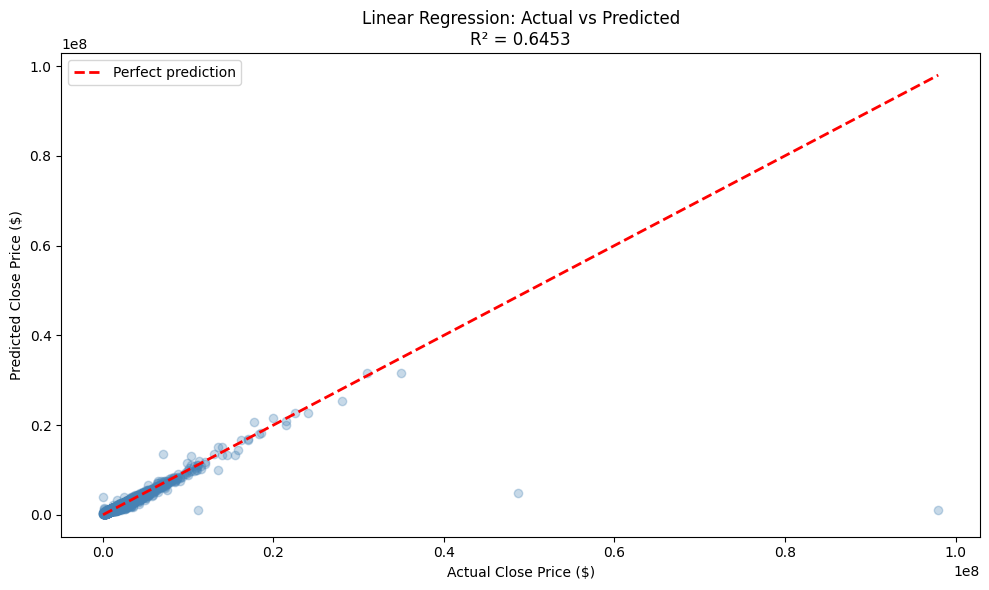

In [18]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color="steelblue")
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--", linewidth=2, label="Perfect prediction"
)
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title(f"Linear Regression: Actual vs Predicted\nR² = {r2_lr:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

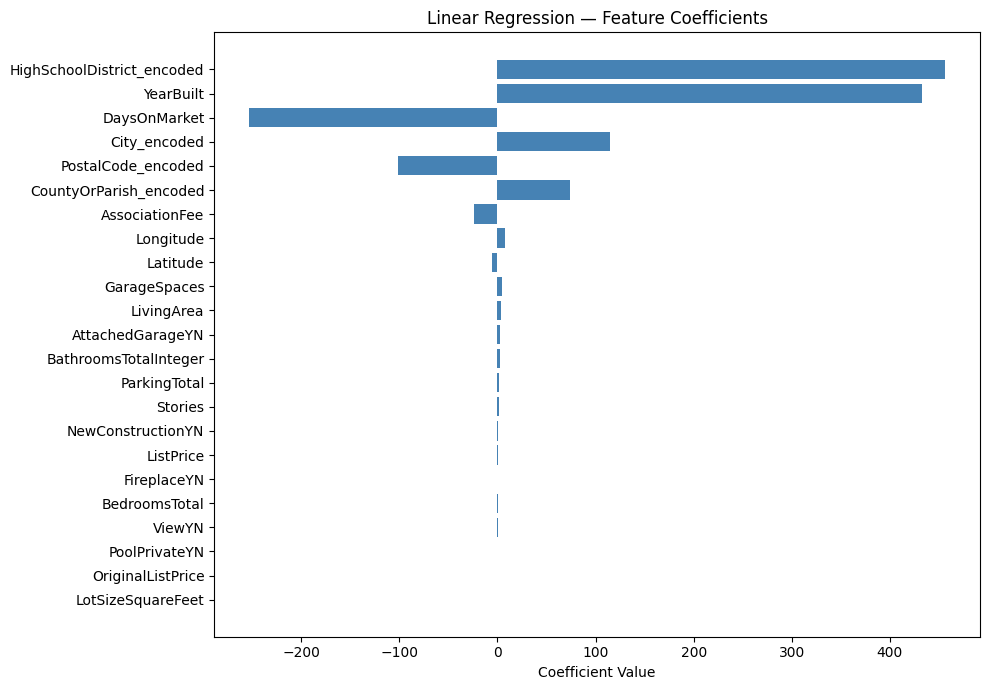

                   Feature  Coefficient
HighSchoolDistrict_encoded   456.385350
                 YearBuilt   432.401845
              DaysOnMarket  -253.164186
              City_encoded   114.387428
        PostalCode_encoded  -100.873691
    CountyOrParish_encoded    73.630177
            AssociationFee   -24.098586
                 Longitude     7.693065
                  Latitude    -5.305992
              GarageSpaces     4.272477
                LivingArea     3.832909
          AttachedGarageYN     2.897215
     BathroomsTotalInteger     2.425862
              ParkingTotal     1.501819
                   Stories     1.358847
         NewConstructionYN     0.958700
                 ListPrice     0.892054
               FireplaceYN    -0.650241
             BedroomsTotal     0.626938
                    ViewYN     0.440719
             PoolPrivateYN    -0.083145
         OriginalListPrice    -0.000371
         LotSizeSquareFeet    -0.000139


In [19]:
# Show which features Linear Regression weighted most
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model_lr.coef_
}).reindex(pd.Series(model_lr.coef_).abs().sort_values(ascending=False).index)

importance = importance.sort_values("Coefficient", key=abs, ascending=False)

plt.figure(figsize=(10, 7))
plt.barh(importance["Feature"], importance["Coefficient"], color="steelblue")
plt.xlabel("Coefficient Value")
plt.title("Linear Regression — Feature Coefficients")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance.to_string(index=False))

In [20]:
results = pd.DataFrame({
    "Model": ["Linear Regression (Baseline)"],
    "R2_Score": [round(r2_lr, 4)],
    "MAE": [round(mae_lr, 0)],
    "Test_Month": ["2026-05"]
})

print(results)

results.to_csv(
    r"C:\Users\linji\OneDrive\Desktop\IDXExchange\ca-price-prediction\data\model_results.csv",
    index=False
)
print("\nResults saved!")

                          Model  R2_Score       MAE Test_Month
0  Linear Regression (Baseline)    0.6453  165686.0    2026-05

Results saved!
